In [2]:
import rdkit
from rdkit import Chem
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
from rdkit import RDLogger
from statistics import median
import os

In [1]:
from rdkit.Chem import Descriptors

def check_lipinski(smiles):
    """
    Check if a SMILES string satisfies Lipinski's Rule of Five.
    
    Returns True if all rules are satisfied, False otherwise.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    return (mw <= 500 and 
            logp <= 5 and 
            hbd <= 5 and 
            hba <= 10)

In [ ]:
import numpy as np
import seaborn as sns

In [5]:
#Import iMiner here
from iMiner.rl_generate.evaluators.drug_likeliness import DrugLikeliness

In [6]:
dl = DrugLikeliness()
smiles = ['C']
dl.calc_score(smiles[0])

1.0965653512511029

In [3]:
sl2k_docking_score_directories ="""._2025_06_23_18_42_28
._2025_06_23_20_30_08
._2025_06_23_21_52_53
._2025_06_23_23_15_43
._2025_06_24_00_40_27
._2025_06_24_02_06_43
._2025_06_24_03_30_53
._2025_06_24_04_57_53
._2025_06_24_06_35_28
._2025_06_24_08_08_24
._2025_06_24_09_49_44
._2025_06_24_11_21_40
._2025_06_24_12_54_34
._2025_06_24_14_41_25
._2025_06_24_16_23_01
._2025_06_24_18_12_12""".split('\n')

In [ ]:
all_sl2k_vina_scores = []
all_sl2k_dl_scores = []
for dsd in tqdm(sl2k_docking_score_directories):
    vina_scores = []
    dl_scores = []
    csv_path = f'run/{dsd}/docking/results/1.csv'
    with open(csv_path, 'r') as csv:
        for line in csv:
            try:
                smiles = line.split(',')[1]
                if smiles != "smiles":
                    score_str = line.split(',')[2]
                    try:
                        score = float(score_str)
                    except:
                        score = 0
                    try:
                        dl_score = dl.calc_score(smiles)
                    except:
                        dl_score = 0
                    vina_scores.append(score)
                    dl_scores.append(dl_score)
            except:
                print(csv_path)
                print(line)
    all_sl2k_vina_scores.append(vina_scores)
    all_sl2k_dl_scores.append(dl_scores)

In [ ]:
all_iminer_vina_scores = []
all_iminer_dl_scores = []
for k in tqdm(range(1,61)):
    smiles = set(['smiles'])
    iminer_vina_scores = []
    iminer_dl_scores = []
    csv_path = f'iminer_ref_details/{k}.csv'
    with open(csv_path, 'r') as csv:
        for line in csv:
            vina_score_str = line.split(',')[1]
            dl_score_str = line.split(',')[2]
            try:
                vina_score = float(vina_score_str)
            except:
                vina_score = 0
            try:
                dl_score = float(dl_score_str)
            except:
                dl_score = 0
            iminer_vina_scores.append(vina_score)
            iminer_dl_scores.append(dl_score)
    all_iminer_vina_scores.append(iminer_vina_scores)
    all_iminer_dl_scores.append(iminer_dl_scores)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

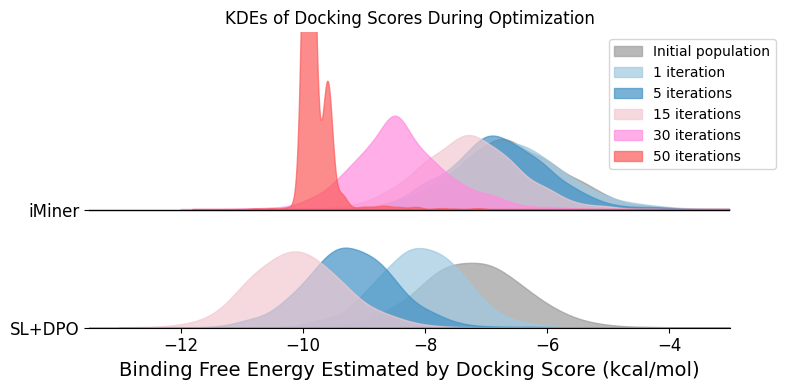

In [15]:
np.random.seed(0)

methods = ['iMiner', 'SL+DPO (2k)', 'SL+DPO (1k)']
stages = ['Init pop', '2000 oracle calls', '10000 oracle calls', '20000 oracle calls']
colors = {
    'Initial population': '#9c9c9c',
    '1 iteration': '#9ecae1',
    '5 iterations': '#4292c6',
    '13 iterations': 'green',
    '15 iterations': '#f2c9d1',
    '30 iterations': '#ff8cde',
    '50 iterations': '#fc5b5b'
}

data = []
data.append({'Fitness': np.array(all_iminer_vina_scores[0]), 'Method': 'iMiner', 'Stage': 'Initial population'})
data.append({'Fitness': np.array(all_iminer_vina_scores[1]), 'Method': 'iMiner', 'Stage': '1 iteration'})
data.append({'Fitness': np.array(all_iminer_vina_scores[5]), 'Method': 'iMiner', 'Stage': '5 iterations'})
data.append({'Fitness': np.array(all_iminer_vina_scores[15]), 'Method': 'iMiner', 'Stage': '15 iterations'})
data.append({'Fitness': all_iminer_vina_scores[30], 'Method': 'iMiner', 'Stage': '30 iterations'})
data.append({'Fitness': all_iminer_vina_scores[50], 'Method': 'iMiner', 'Stage': '50 iterations'})

data.append({'Fitness': np.array(all_sl2k_vina_scores[0]), 'Method': 'SL+DPO (2k)', 'Stage': 'Initial population'})
data.append({'Fitness': np.array(all_sl2k_vina_scores[1]), 'Method': 'SL+DPO (2k)', 'Stage': '1 iteration'})
data.append({'Fitness': np.array(all_sl2k_vina_scores[5]), 'Method': 'SL+DPO (2k)', 'Stage': '5 iterations'})
data.append({'Fitness': np.array(all_sl2k_vina_scores[15]), 'Method': 'SL+DPO (2k)', 'Stage': '15 iterations'})

# Plot setup
plt.figure(figsize=(8, 4))
y_offsets = {'iMiner': 0.8, 'SL+DPO (2k)': 0.0}

for entry in data:
    fitness = entry['Fitness']
    method = entry['Method']
    stage = entry['Stage']
    color = colors[stage]
    y_offset = y_offsets[method]
    #print(method, stage, fitness)

    kde = gaussian_kde(fitness, bw_method=0.22)
    x_vals = np.linspace(min(fitness) - 1, max(fitness) + 1, 1000)
    density = kde(x_vals)

    plt.fill_between(x_vals, y_offset, y_offset + density, alpha=0.7, color=color, label=stage)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

#Make it pretty
plt.title('KDEs of Docking Scores During Optimization')

plt.xlabel('Binding Free Energy Estimated by Docking Score (kcal/mol)', fontsize=14)
plt.xlim(-13.5, -3)
plt.xticks(fontsize=12)

for y in y_offsets.values():
    plt.axhline(y, color='black', linewidth=1)
plt.yticks([0.8, 0], ['iMiner', 'SL+DPO'], fontsize=12)
plt.ylim(0, 2)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(0.80, 1), loc='upper left')
plt.tight_layout()
plt.savefig('docking_kde.png', dpi=300)
plt.show()

In [17]:
def score(smiley):
    m = Chem.MolFromSmiles(smiley)
    if m is not None:
        return QED.qed(m)
    else:
        return -1

def valid_and_unique(smiles_list):
    num_valid = 0
    scores = []
    canonical_smiles = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(s)
        if m is not None:
            num_valid += 1
            canonical_smiles.append(Chem.MolToSmiles(m))
    percent_valid = num_valid/len(smiles_list)*100
    percent_unique = len(set(canonical_smiles))/len(canonical_smiles)*100
    return {'Number of iterations valid': percent_valid, 'Number of iterations unique': percent_unique}

def valid_unique_novel(smiles_list, dataset): # Dataset is what novelty is assessed with respect to
    num_valid = 0
    scores = []
    canonical_smiles = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(s)
        if m is not None:
            num_valid += 1
            canonical_smiles.append(Chem.MolToSmiles(m))
    num_non_novel = 0
    for s in canonical_smiles:
        if s in dataset:
            num_non_novel += 1
    percent_valid = num_valid/len(smiles_list)*100
    percent_unique = len(set(canonical_smiles))/len(canonical_smiles)*100
    percent_novel = (len(canonical_smiles) - num_non_novel)/len(canonical_smiles)*100
    dataset.update(canonical_smiles)
    return percent_valid, percent_unique, percent_novel, dataset

In [18]:
iminer_v = []
iminer_u = []
iminer_n = []
prev_can_smiles = set([])

for l in tqdm(range(1, 52)):
    try:
        smiles_path = 'iminer_ref_details/'+str(l)+'.csv'
        with open(smiles_path, 'r') as fil:
            lines = fil.readlines()[1:2001] # First line is header
        smiles = [l.split(",")[0].rstrip() for l in lines]
        v, u, n, prev_can_smiles = valid_unique_novel(smiles, prev_can_smiles)
        iminer_v.append(v)
        iminer_u.append(u)
        iminer_n.append(n)
    except Exception as e:
        print(e)
        pass

100%|██████████| 51/51 [00:32<00:00,  1.58it/s]


100%|██████████| 16/16 [00:07<00:00,  2.04it/s]


In [20]:
job_dir='run/'

sl2k_v = []
sl2k_u = []
sl2k_n = []
prev_can_smiles = set([])

for l in tqdm(range(1, 17)):
    try:
        smiles_path = os.path.join(job_dir, 'sample_SARS2PRO_iter'+str(l)+'.txt')
        with open(smiles_path, 'r') as fil:
            lines = fil.readlines()[0:2000]
        smiles = [l.rstrip() for l in lines]
        v, u, n, prev_can_smiles = valid_unique_novel(smiles, prev_can_smiles)
        sl2k_v.append(v)
        sl2k_u.append(u)
        sl2k_n.append(n)
    except Exception as e:
        print(e)
        pass

100%|██████████| 16/16 [00:28<00:00,  1.78s/it]


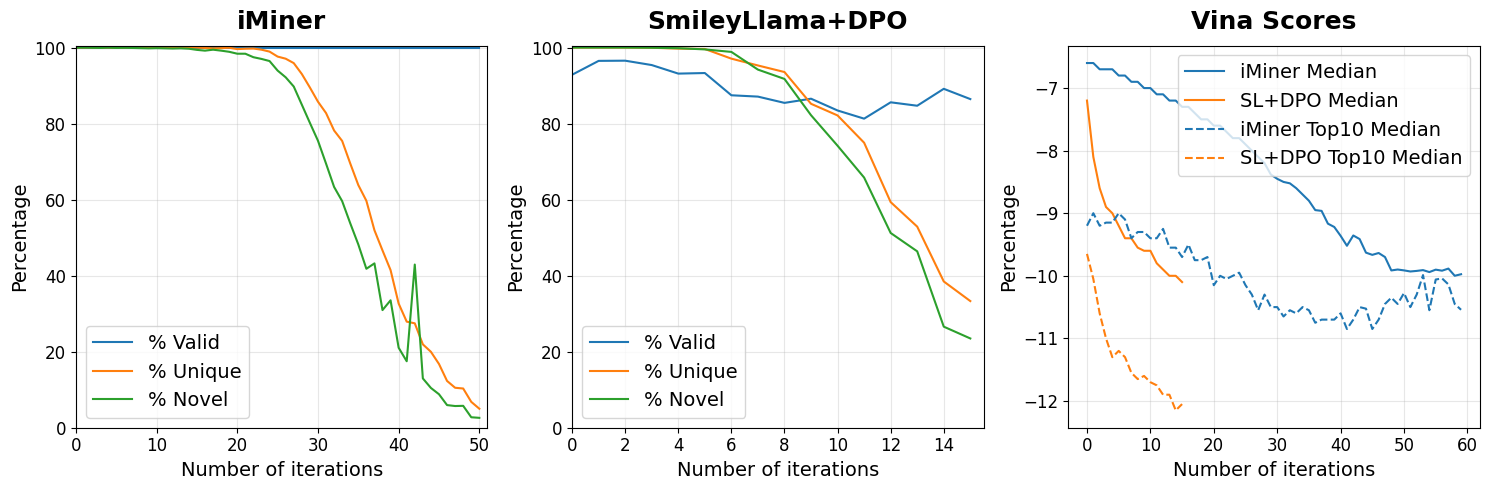

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import median

TITLE_SIZE = 18
LABEL_SIZE = 14
LEGEND_SIZE = 14
TICK_SIZE = 12

iminer_x = range(0, 51)
sl_x = range(0, 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

ax1.plot(iminer_x, iminer_v, label='% Valid', color='#1f77b4')
ax1.plot(iminer_x, iminer_u, label='% Unique', color='#ff7f0e')
ax1.plot(iminer_x, iminer_n, label='% Novel', color='#2ca02c')
ax1.set_xlim(0, 51)
ax1.set_ylim(0, 100.5)
ax1.set_title('iMiner', fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax1.set_xlabel('Number of iterations', fontsize=LABEL_SIZE)
ax1.set_ylabel('Percentage', fontsize=LABEL_SIZE)
ax1.legend(fontsize=LEGEND_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
ax1.grid(True, alpha=0.3)

ax2.plot(sl_x, sl2k_v, label='% Valid', color='#1f77b4')
ax2.plot(sl_x, sl2k_u, label='% Unique', color='#ff7f0e')
ax2.plot(sl_x, sl2k_n, label='% Novel', color='#2ca02c')
ax2.set_xlim(0, 15.5)
ax2.set_ylim(0, 100.5)
ax2.set_title('SmileyLlama+DPO', fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax2.set_xlabel('Number of iterations', fontsize=LABEL_SIZE)
ax2.set_ylabel('Percentage', fontsize=LABEL_SIZE)
ax2.legend(fontsize=LEGEND_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
ax2.grid(True, alpha=0.3)


x_axis = list(range(0, 50))
iminer_medians = [median(item) for item in all_iminer_vina_scores]
iminer_top10_medians = [median(sorted(s)[:10]) for s in all_iminer_vina_scores]
sl_medians = [median(item) for item in all_sl2k_vina_scores]
sl_top10_medians = [median(sorted(s)[:10]) for s in all_sl2k_vina_scores]

ax3.plot(iminer_medians, label='iMiner Median', color='#1f77b4')
ax3.plot(sl_medians, label='SL+DPO Median', color='#ff7f0e')
ax3.plot(iminer_top10_medians, label='iMiner Top10 Median', color='#1f77b4', linestyle='dashed')
ax3.plot(sl_top10_medians, label='SL+DPO Top10 Median', color='#ff7f0e', linestyle='dashed')
#ax3.set_xlim(0, 15.5)
#ax3.set_ylim(0, 100.5)
ax3.set_title('Vina Scores', fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax3.set_xlabel('Number of iterations', fontsize=LABEL_SIZE)
ax3.set_ylabel('Percentage', fontsize=LABEL_SIZE)
ax3.legend(fontsize=LEGEND_SIZE)
ax3.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('optimization_vun', dpi=600)

plt.show()